<a href="https://colab.research.google.com/github/ibrahimhanifceker/YZ50Hafta1/blob/main/YZ50Hafta1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Tek Nöron Forward Pass

Not: Kullandığım tek kütüphane Python Standard Library'den "random" kütüphanesi. Onu kullanma sebebim de weight ve bias değerlerinin rastgele bir şekilde belirlenmesini sağlayıp modelin farklı değerler için eğitilebildiğini kotrol etmekti. Belirli bir seed değeri belirleyerek de reproducibility sağladım böylece benim kod sizin için de aynı değerleri verecektir.



In [95]:
import random

random.seed(42)

class Neuron:
    def __init__(self) :
        self.weight = random.uniform(-1, 1)
        self.bias = random.uniform(-1, 1)

    def __call__(self, x):
        self.out = self.weight * x + self.bias
        return self.out

my_neuron = Neuron()
my_neuron(5)

0.44428949502417137

# 2. Birden Fazla Nöronlu Katman

Burada istenen katmanın tek bir input değeri alacağını varsaydım ve input katmanı dışında tek bir katman içeren (aynı zamanda output katmanı ve 3 nöronlu) basit bir neural network oluşturdum.

In [96]:
class Layer:
    def __init__(self, num_neurons):
        self.neurons = [Neuron() for _ in range(num_neurons)]

    def __call__(self, x):
        self.out = [neuron(x) for neuron in self.neurons]
        return self.out

layer = Layer(3)
layer(5)

[-2.803285340011162, 2.7181111164859466, 3.095673342307286]

# 3. Basit Loss Fonksiyonu

Loss fonksiyonu olarak MSE seçtim fakat tek farkı burada tek bir batch için loss hesaplamış olduğum için ortalama (mean) değerini hesaplamıyorum.

In [97]:
def loss_function(input, target):
    return sum((a - b) ** 2 for a, b in zip(input, target))

# 4.1 Parametreleri Manuel Değiştirme

In [98]:
target = [3, -1, 4]
input = 2

print("Nöron 1 weight:")
layer.neurons[1].weight = -1
print(loss_function(layer(input), target))
layer.neurons[1].weight = -0.5
print(loss_function(layer(input), target))
layer.neurons[1].weight = 0.5
print(loss_function(layer(input), target))
layer.neurons[1].weight = 1
print(loss_function(layer(input), target))

print("\nNöron 2 bias:")
layer.neurons[1].bias = -5
print(loss_function(layer(input), target))
layer.neurons[1].bias = -3
print(loss_function(layer(input), target))
layer.neurons[1].bias = 0
print(loss_function(layer(input), target))

Nöron 1 weight:
30.862091228648037
30.56888917833968
35.98248507772297
41.68928302741462

Nöron 2 bias:
34.4439983429176
30.443998342917602
39.4439983429176


# 4.2 Loss eğrisini Çizme

Loss'un nasıl değiştiğini görmek için tek bir parametreyi değiştirdim.

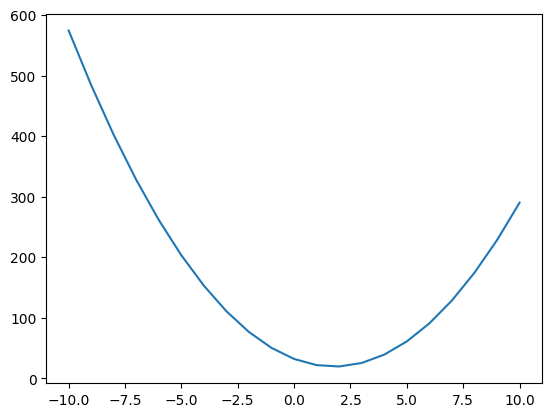

In [99]:
import matplotlib.pyplot as plt

param_vals = list(range(-10, 11))
param_outs = []
for param_val in param_vals:
    layer.neurons[0].weight = param_val
    param_outs.append(loss_function(layer(input), target))

plt.plot(param_vals, param_outs)

# 5. Gradient Descent Döngüsü

In [100]:
learning_rate = 0.05

epochs = 20

print(loss_function(layer(input), target))

for epoch in range(epochs):
    for trg, neuron in zip(target, layer.neurons):
        loss_grad = 2 * (neuron.out - trg)
        weight_grad = input * loss_grad
        bias_grad = loss_grad
        neuron.weight += -learning_rate * weight_grad
        neuron.bias += -learning_rate * bias_grad
    print(loss_function(layer(input), target))


290.09546061167856
72.52386515291964
18.13096628822991
4.532741572057473
1.1331853930143694
0.2832963482535918
0.07082408706339809
0.017706021765849504
0.004426505441462393
0.0011066263603655955
0.000276656590091406
6.916414752284721e-05
1.7291036880711803e-05
4.322759220178667e-06
1.080689805044755e-06
2.7017245126167864e-07
6.754311281562047e-08
1.6885778203971878e-08
4.2214445509540714e-09
1.0553611377329997e-09
2.638402844388357e-10
